# maply quickstart

Draw shapes interactively and convert them to shapely / WKT / GeoJSON / GeoDataFrame.

**How to draw**

- **Point** – click once per point.
- **Line** – click each vertex, then press **Finish**.
- **Polygon** – click each vertex; click back near the first vertex (or press **Finish**) to close.
- **Rectangle / Circle** – press and drag, then release.

Use **Undo** to drop the last vertex/shape and **Clear** to start over.

In [27]:
from maply import MaplyCanvas

canvas = MaplyCanvas(width=600, height=200)
canvas

MaplyCanvas(children=(VBox(children=(ToggleButtons(description='Tool:', index=2, options=(('Point', <Tool.POIN…

## Pull the shapes back into Python

After drawing, run the cells below.

In [36]:
# WKT strings
canvas.wkt

['POLYGON ((162.65060240963857 167.06827309236948, 294.37751004016064 168.27309236947792, 297.5903614457831 106.02409638554217, 251.80722891566265 116.86746987951807, 255.02008032128515 85.5421686746988, 299.5983935742972 82.3293172690763, 302.00803212851406 50.20080321285141, 152.61044176706827 49.79919678714859, 162.65060240963857 167.06827309236948))']

In [37]:
# shapely geometry objects
canvas.geometries

[<POLYGON ((162.651 167.068, 294.378 168.273, 297.59 106.024, 251.807 116.867...>]

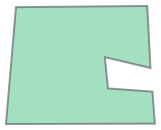

In [38]:
# A single GeometryCollection (handy for spatial-algorithm inputs)
canvas.to_collection()

In [39]:
# GeoJSON FeatureCollection
canvas.geojson

{'type': 'FeatureCollection',
 'features': [{'type': 'Feature',
   'properties': {'kind': 'polygon'},
   'geometry': {'type': 'Polygon',
    'coordinates': (((162.65060240963857, 167.06827309236948),
      (294.37751004016064, 168.27309236947792),
      (297.5903614457831, 106.02409638554217),
      (251.80722891566265, 116.86746987951807),
      (255.02008032128515, 85.5421686746988),
      (299.5983935742972, 82.3293172690763),
      (302.00803212851406, 50.20080321285141),
      (152.61044176706827, 49.79919678714859),
      (162.65060240963857, 167.06827309236948)),)}}]}

In [40]:
# GeoDataFrame (requires the geopandas extra)
canvas.to_geodataframe()

,kind,geometry
0,polygon,"POLYGON ((162.651 167.068, 294.378 168.273, 29..."


## No drawing required — build shapes in code

The model + geometry layers are pure Python, so you can also assemble shapes
programmatically (useful for tests and MREs).

In [41]:
from maply.geometry import to_wkt
from maply.model import Shape
from maply.tools import Tool

square_with_hole = Shape(
    kind=Tool.POLYGON,
    exterior=[(0, 0), (10, 0), (10, 10), (0, 10)],
    holes=[[(3, 3), (6, 3), (6, 6), (3, 6)]],
)
to_wkt([square_with_hole])


['POLYGON ((0 0, 10 0, 10 10, 0 10, 0 0), (3 3, 6 3, 6 6, 3 6, 3 3))']

## Draw on a real map — `GeoCanvas`

`GeoCanvas` embeds a full [ipyleaflet](https://ipyleaflet.readthedocs.io) map:
pan, zoom, basemaps, and a draw/edit/delete toolbar. maply supplies the
pure-Python glue in **both directions**:

- **map → Python:** drawn features become shapely / WKT / GeoJSON / GeoDataFrame.
- **Python → map:** push a shapely geometry, WKT, or GeoDataFrame onto the map
  (optionally editable) — great for inspecting a spatial algorithm's output.

Requires the `geo` extra: `pip install maply[geo]`.


In [34]:
from shapely.geometry import Polygon

from maply import GeoCanvas

geo = GeoCanvas(center=(37.77, -122.42), zoom=12)

# Python -> map: drop a shapely polygon on the map, editable with the toolbar
aoi = Polygon([(-122.45, 37.75), (-122.40, 37.75), (-122.40, 37.79), (-122.45, 37.79)])
geo.add_geometry(aoi, kind="aoi")
geo


GeoCanvas(children=(Map(center=[37.77, -122.42], controls=(ZoomControl(options=['position', 'zoom_in_text', 'z…

In [35]:
# map -> Python: draw/edit on the map above, then re-run this cell.
# Includes the injected AOI plus anything you draw (circles are polygonised).
print(geo.wkt)
geo.to_geodataframe()          # lon/lat, crs=EPSG:4326  (pass crs=... to reproject)


['POLYGON ((-122.45 37.75, -122.4 37.75, -122.4 37.79, -122.45 37.79, -122.45 37.75))']


,kind,geometry
0,Polygon,"POLYGON ((-122.45 37.75, -122.4 37.75, -122.4 ..."
